In [25]:
# load python packages
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import QS_functions as QSfunc

In [72]:
window = 24      # 6/12/24-hour window for along-track calculation
# Dataframe of Medcyclone tracks that have crossed the Mediterranean, with mobility metrics
df_Medcrossers = pd.read_csv(f'../output/TRACKS_CL5_QS_{window}h_Medcrossers.csv', header=0)
print(df_Medcrossers.head())

# dataframes filtering for Quasi-Stationary Medcyclones based on different metrics
df_QS_FT_MED_VEL = df_Medcrossers[df_Medcrossers['FT_MED_VEL_c'] == 1]
df_QS_MED_VEL = df_Medcrossers[df_Medcrossers['AT_MED_VEL_c'] == 1]
df_QS_DIST = df_Medcrossers[df_Medcrossers['AT_DIST_c'] == 1]
df_QS_RAD_DIST = df_Medcrossers[df_Medcrossers['AT_RAD_DIST_c'] == 1]
df_QS_CIRCLE_DIST = df_Medcrossers[df_Medcrossers['AT_CIRCLE_DIST_c'] == 1]

   id    lon     lat  year  month  day  time      hPa  FT_MED_VEL_v  \
0   4  0.960  40.700  1979      1    8    18  1016.93        31.008   
1   4  1.080  40.761  1979      1    8    19  1016.93        31.008   
2   4  1.300  40.746  1979      1    8    20  1016.64        31.008   
3   4  1.624  40.699  1979      1    8    21  1016.35        31.008   
4   4  1.986  40.693  1979      1    8    22  1015.86        31.008   

   FT_MED_VEL_q  ...  AT_MED_VEL_c  AT_DIST_v  AT_DIST_q  AT_DIST_c  \
0         0.831  ...           0.0    693.153      0.701        0.0   
1         0.831  ...           0.0    720.808      0.728        0.0   
2         0.831  ...           0.0    737.839      0.745        0.0   
3         0.831  ...           0.0    745.031      0.751        0.0   
4         0.831  ...           0.0    751.994      0.758        0.0   

   AT_RAD_DIST_v  AT_RAD_DIST_q  AT_RAD_DIST_c  AT_CIRCLE_DIST_v  \
0       6966.621          0.625            0.0           649.391   
1       73

In [73]:
def track_density_plot(ax, df_tracks, l_density, box_lonlat, res_degree, levels, cmap, title):
    """Plot df_tracks density on a map."""
    
    # Define white as zero cmap density
    cmap.set_under('white')

    # Add gridlines with labels for longitude and latitude
    gridlines = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gridlines.top_labels = False
    gridlines.right_labels = False

    # Add features to the map
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE)

    # Set histogram bins coordinates and extent
    lon_bins = np.arange(box_lonlat[0], box_lonlat[1]+res_degree, res_degree)
    lat_bins = np.arange(box_lonlat[2], box_lonlat[3]+res_degree, res_degree)
    ax.set_extent(box_lonlat, crs=ccrs.PlateCarree())

    # Plot the 2D histogram on the map
    h_norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=plt.get_cmap(cmap).N, extend='max')
    h = ax.hist2d(
        df_tracks['lon'], df_tracks['lat'], 
        bins=[lon_bins, lat_bins], cmap=cmap, 
        transform=ccrs.PlateCarree(), norm=h_norm, density=l_density
    )
    # Colorbar
    cbar = plt.colorbar(
        h[3], ax=ax, orientation='vertical', shrink=0.8, # pad=0.02,
        ticks=levels, extend='max',
    )
    cbar.ax.set_yticklabels([str(l) for l in levels])

    # Set labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if l_density:
        str_density = 'Relative Density'
    else:
        str_density = 'Density'
    cbar.set_label(str_density)
    ax.set_title(f'{str_density} of {title}')
    return ax
    

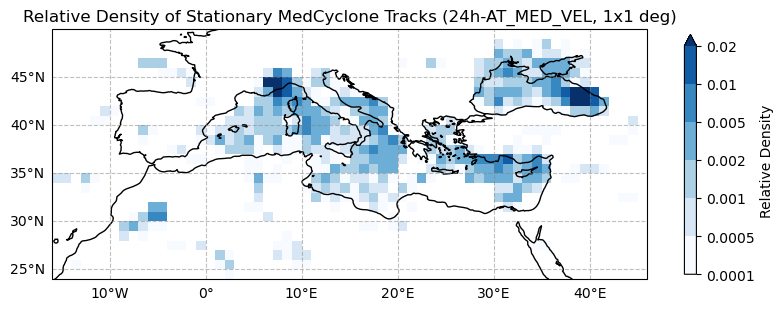

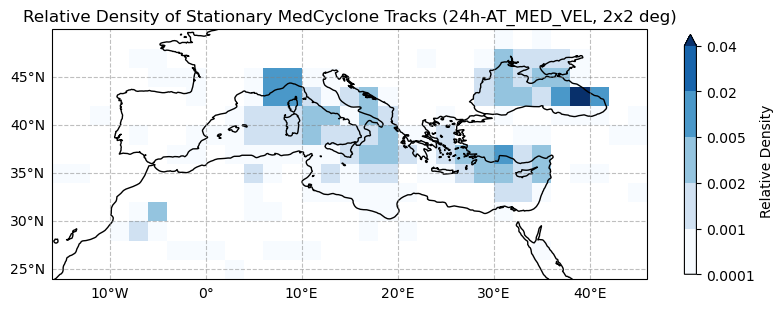

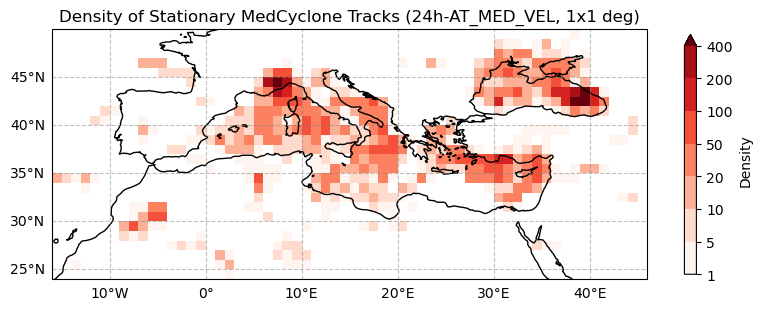

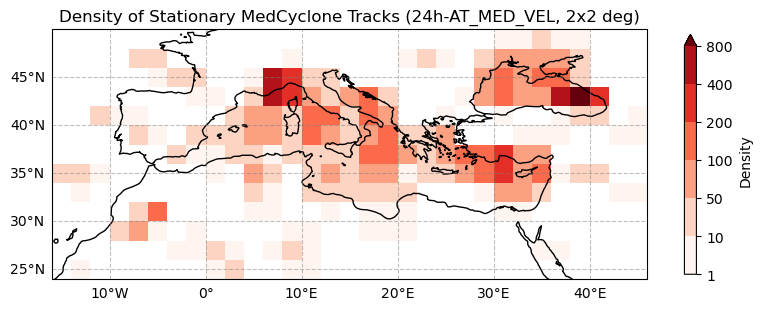

In [74]:
# Choice of data to plot
MedC_def = 'AT_MED_VEL'  # 'FT_MED_VEL' or '12h_MED_VEL' '12h_DIST' or '12h_RAD_DIST' or '12h_CIRCLE_DIST' or 'all'
if MedC_def == 'FT_MED_VEL':
    df_plot = df_QS_FT_MED_VEL
elif MedC_def == 'AT_MED_VEL':
    df_plot = df_QS_MED_VEL
elif MedC_def == 'AT_DIST':
    df_plot = df_QS_DIST
elif MedC_def == 'AT_RAD_DIST':
    df_plot = df_QS_RAD_DIST
elif MedC_def == 'AT_CIRCLE_DIST':
    df_plot = df_QS_CIRCLE_DIST
elif MedC_def == 'all':
    df_plot = df_Medcrossers
list_l_dens = [True, False]  # True for relative density, False for absolute density
list_degree_step = [1,2]

# Density plot parameters
box = [-16, 46, 24, 50]  # [lon_min, lon_max, lat_min, lat_max]
for l_dens in list_l_dens:
    for degree_step in list_degree_step:
        # title
        if MedC_def == 'all':
            plot_title = f'MedCyclone Tracks ({degree_step}x{degree_step} deg)'
            factor = 10  # to adjust colorbar scale for all MedCs
        else:
            if MedC_def[:2]=='AT':
                MedC_def = f'{window}h-{MedC_def}'
            plot_title = f'Stationary MedCyclone Tracks ({MedC_def}, {degree_step}x{degree_step} deg)'
            factor = 1
        
        # levels and colormap
        if l_dens:
            if degree_step == 1:
                h_levels = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
            elif degree_step == 2:
                h_levels = [0.0001, 0.001, 0.002, 0.005, 0.02, 0.04] #, 1000]
            cmap = plt.cm.Blues
            fig_name = 'density-rel'
        else:
            if degree_step == 1:
                h_levels = np.array([1, 5, 10, 20, 50, 100, 200, 400]) * factor
            elif degree_step == 2:   
                h_levels = np.array([1, 10, 50, 100, 200, 400, 800]) * factor
            cmap = plt.cm.Reds
            fig_name = 'density-abs'
        
        # Create a figure and axis with a map projection
        fig = plt.figure(figsize=(8, 3.3))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Plot density
        track_density_plot(ax, df_plot, l_dens, box, degree_step, h_levels, cmap, plot_title)
        
        fig.tight_layout(rect=[0, 0, 1.02, 1]) # left, bottom, right, top
        plt.show()
        fig.savefig(f'../output/figures/{fig_name}_{MedC_def}_{degree_step}deg.png', dpi=300)